# PS-S06E06: LightGBM

This notebook tackles the [**Playground Series – Season 6, Episode 6: Predicting Stellar Class**](https://www.kaggle.com/competitions/playground-series-s6e6), a competition focused on predicting a class label (`GALAXY`, `QSO`, `STAR`) for the `class` target, based on features describing the position, light intensity across SDSS photometric bands, redshift, spectral type, and galaxy population for each observed object.

## Introduction

**LightGBM** distinguishes itself with a leaf-wise (best-first) tree growth strategy, contrasting with the level-wise approach used by XGBoost. This allows it to converge faster and often capture more complex, non-linear dependencies. It handles missing values internally and is highly optimized for memory efficiency and training speed. LightGBM has native support for categorical features — `spectral_type` and `galaxy_population` are passed as `category` dtype and handled natively without manual encoding.

This notebook is one of several exploring different models for this challenge. The EDA was performed in: [**PS-S06E06: EDA**](https://www.kaggle.com/code/stephentarter/ps-s06e06-eda).

## Install Needed Packages

In [1]:
%pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import gc
import sys
import json
import math
import time
import random
import warnings
import logging
from pathlib import Path
from typing import Iterable
from IPython.display import display, Markdown, IFrame

# Third-party
import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna
from optuna.exceptions import TrialPruned
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt
import seaborn as sns

from ps_s06e06_feature_engineering import FeatureFactory
from ps_s06e06_model_visualizer import ModelVisualizer
from ps_s06e06_experiment_setup import ExperimentSetup

warnings.filterwarnings('ignore')
logging.getLogger('lightgbm').setLevel(logging.ERROR)

%matplotlib inline

import ipywidgets as widgets
widgets.IntProgress()

IntProgress(value=0)

In [3]:
setup = ExperimentSetup(
    model_name='LightGBM',
    use_gpu=True,
    perform_rfe=False,
    perform_optuna_tuning=False
)

seed = setup.set_seeds()

setup.configure_pandas()
setup.suppress_warnings()

# The target feature
TARGET = 'class'

# Class label mapping (must be consistent everywhere)
target_mapping = {'QSO': 0, 'STAR': 1, 'GALAXY': 2}
inverse_target_mapping = {v: k for k, v in target_mapping.items()}

setup.describe()

Random seed set to: 10301
Warnings suppressed.

Experiment Setup
Model         : LightGBM
Target        : class
Use GPU       : True
RFE           : True
Optuna Tuning : True 
On Kaggle     : False


## Read and Examine the Training Dataset

In [4]:
training_df = setup.get_combined_training_data()
train_ids = training_df['id'].copy()

TRAINING DATASET

   id   alpha  delta      u      g      r      i      z  redshift  \
0   0 147.734 16.959 25.472 21.896 20.358 19.257 18.621     0.409   
1   1 127.989 32.347 20.779 19.087 17.587 17.226 16.786     0.158   
2   2 179.793 35.345 21.035 21.079 21.172 20.583 20.557     2.824   
3   3 225.818 48.569 23.305 21.051 19.018 18.366 17.915     0.536   
4   4 141.836 19.343 21.703 19.472 18.234 17.899 17.616     0.556   

  spectral_type galaxy_population   class  is_original  
0             M      Red_Sequence  GALAXY        False  
1             M      Red_Sequence  GALAXY        False  
2           O/B        Blue_Cloud     QSO        False  
3             M      Red_Sequence  GALAXY        False  
4             M      Red_Sequence  GALAXY        False  
ORIGINAL DATASET

                         obj_ID   alpha  delta      u      g      r      i  \
0 1,237,660,961,327,743,232.000 135.689 32.495 23.879 22.275 20.395 19.166   
1 1,237,664,879,951,151,104.000 144.826 31.274 24.7

## Read and Examine the Test Dataset

In [5]:
test_df = setup.read_dataset("test")
test_ids  = test_df['id'].copy()

TEST DATASET

       id   alpha  delta      u      g      r      i      z  redshift  \
0  577347 120.720 23.924 23.668 21.952 21.086 20.180 19.202     0.429   
1  577348 219.414 42.172 24.903 22.339 20.732 19.860 19.688     0.867   
2  577349 173.569 -1.756 19.428 18.475 17.551 16.571 16.177     0.224   
3  577350 184.904 -1.411 23.121 21.527 20.670 20.418 20.699     0.067   
4  577351 222.488 15.381 25.094 22.644 21.123 19.440 19.094     0.977   

  spectral_type galaxy_population  is_original  
0           G/K      Red_Sequence        False  
1             M      Red_Sequence        False  
2           G/K        Blue_Cloud        False  
3           G/K      Red_Sequence        False  
4             M      Red_Sequence        False  


## Feature Engineering

LightGBM handles `category` dtype natively, so `spectral_type` and `galaxy_population` are cast directly without ordinal encoding. The full strategy set mirrors the XGBoost notebook:

- `encoding` — Casts `spectral_type` (ordered O/B→M) and `galaxy_population` to `category` dtype
- `colors` — SDSS photometric colour indices (`u-g`, `g-r`, `r-i`, `i-z`, wider-baseline combos)
- `ratios` — SED shape features: mean/std magnitude, spectral slope, outer-to-central band ratio
- `redshift` — Redshift-derived features and colour×redshift interaction terms
- `position` — Cartesian sky-coordinate projection and |δ|
- `interactions` — Higher-order cross-feature products


In [6]:
# Define which strategies to use for the LightGBM model here:
fe_strategies = [
    'encoding',       # Cast spectral_type and galaxy_population to category dtype
    'colors',         # SDSS photometric colour indices
    'ratios',         # SED shape features: mean/std magnitude, spectral slope
    'redshift',       # Redshift-derived features and colour×redshift interactions
    'position',       # Sky-coordinate Cartesian projection and |delta|
    'interactions',   # Higher-order cross-feature products
    'flux',
    'numeric_expansion'
]

In [7]:
print('Performing initial feature engineering.')

feature_engineer = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed)

# Encode target labels: QSO=0, STAR=1, GALAXY=2
y = training_df[TARGET].map(target_mapping).astype(int)

X = feature_engineer.fit_transform(training_df)
X_test = feature_engineer.transform(test_df)

# Get categorical columns and cast to category dtype for LightGBM native handling
cat_cols = feature_engineer.get_cat_features(X)
cat_cols = [c for c in cat_cols if c in X.columns]

for c in cat_cols:
    X[c] = X[c].astype('category')
    X_test[c] = X_test[c].astype('category')

print(f'Old Feature Count: {training_df.shape[1] - 1}')
print(f'New Feature Count: {X.shape[1]}')
print(X.head())

Performing initial feature engineering.
Old Feature Count: 10
New Feature Count: 79
  galaxy_population  delta   alpha spectral_type  is_original      g      u  \
0      Red_Sequence 16.959 147.734             M        False 21.896 25.472   
1      Red_Sequence 32.347 127.989             M        False 19.087 20.779   
2        Blue_Cloud 35.345 179.793           O/B        False 21.079 21.035   
3      Red_Sequence 48.569 225.818             M        False 21.051 23.305   
4      Red_Sequence 19.343 141.836             M        False 19.472 21.703   

       z      r  redshift      i  u_minus_g  g_minus_r  r_minus_i  i_minus_z  \
0 18.621 20.358     0.409 19.257      3.577      1.538      1.101      0.636   
1 16.786 17.587     0.158 17.226      1.691      1.500      0.361      0.440   
2 20.557 21.172     2.824 20.583     -0.044     -0.093      0.589      0.025   
3 17.915 19.018     0.536 18.366      2.254      2.033      0.652      0.451   
4 17.616 18.234     0.556 17.899      2.2

## Recursive Feature Elimination

Running Recursive Feature Elimination for LightGBM...
Fitting estimator with 79 features.
Fitting estimator with 78 features.
Fitting estimator with 79 features.
Fitting estimator with 78 features.
Fitting estimator with 77 features.
Fitting estimator with 76 features.
Fitting estimator with 75 features.
Fitting estimator with 74 features.
Fitting estimator with 73 features.
Fitting estimator with 72 features.
Fitting estimator with 71 features.
Fitting estimator with 70 features.
Fitting estimator with 69 features.
Fitting estimator with 68 features.
Fitting estimator with 67 features.
Fitting estimator with 66 features.
Fitting estimator with 65 features.
Fitting estimator with 64 features.
Fitting estimator with 63 features.
Fitting estimator with 62 features.
Fitting estimator with 61 features.
Fitting estimator with 60 features.
Fitting estimator with 59 features.
Fitting estimator with 58 features.
Fitting estimator with 57 features.
Fitting estimator with 56 features.
Fitting es

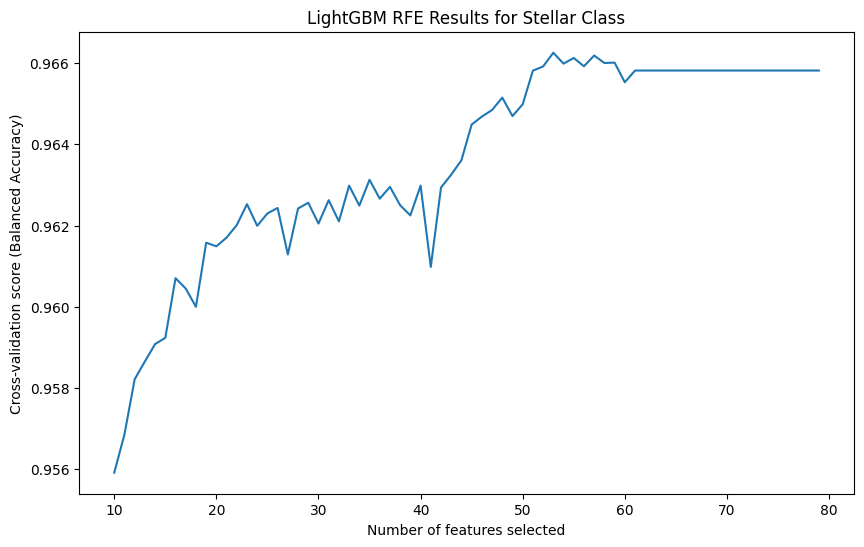

Saved 53 features to selected_features_lgb.json

Optimal Features Count: 53


In [8]:
n_jobs = -1
rfe_filename = 'selected_features_lgb.json'

# Prepare a numeric copy for RFECV (requires numeric types)
X_rfe = X.copy()
cat_cols_rfe = X_rfe.select_dtypes(include=['category', 'object']).columns
for col in cat_cols_rfe:
    X_rfe[col] = X_rfe[col].astype('category').cat.codes

if setup.perform_rfe():
    n_jobs_clf = max(1, os.cpu_count() // 5)   # threads per LightGBM fit
    n_jobs_rfecv = 5                           # one worker per CV fold
    
    clf = lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        num_leaves=31,
        objective='multiclass',
        num_class=3,
        class_weight='balanced',
        random_state=seed,
        n_jobs=n_jobs_clf,
        importance_type='gain',
        verbosity=-1
    )

    rfecv = RFECV(
        estimator=clf,
        step=1,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=seed),
        scoring='balanced_accuracy',
        min_features_to_select=10,
        n_jobs=n_jobs_rfecv,
        verbose=10,
    )

    print('Running Recursive Feature Elimination for LightGBM...')
    rfecv.fit(X_rfe, y)

    print(f'Optimal number of features: {rfecv.n_features_}')

    plt.figure(figsize=(10, 6))
    plt.xlabel('Number of features selected')
    plt.ylabel('Cross-validation score (Balanced Accuracy)')
    plt.plot(
        range(rfecv.min_features_to_select,
              len(rfecv.cv_results_['mean_test_score']) + rfecv.min_features_to_select),
        rfecv.cv_results_['mean_test_score']
    )
    plt.title('LightGBM RFE Results for Stellar Class')
    plt.show()

    optimal_cols = X_rfe.columns[rfecv.support_]
    
    setup.save_rfe(rfe_filename, pd.Index(optimal_cols))
else:
    optimal_cols = setup.load_rfe(rfe_filename, X)

    # If the file is empty, use all of the columns
    if len(optimal_cols) == 0:
        print('\nUsing all features')
        optimal_cols = X.columns

print('\nOptimal Features Count:', len(optimal_cols))


## Optuna Tuning

In [9]:
print("Precomputing fold-wise FE for Optuna (once)...")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
fold_cache = []
fold_fe = []

cols_to_keep = list(optimal_cols) if not isinstance(optimal_cols, list) else optimal_cols

# Only split on competition rows; original rows always go to train
comp_mask = training_df['is_original'] == False
comp_idx = np.where(comp_mask)[0]

for fold, (rel_train_idx, rel_val_idx) in enumerate(skf.split(comp_idx, y.iloc[comp_idx])):
    train_idx = np.concatenate([comp_idx[rel_train_idx], np.where(~comp_mask)[0]])
    val_idx = comp_idx[rel_val_idx]
    X_train_fold = training_df.iloc[train_idx].copy()
    X_val_fold   = training_df.iloc[val_idx].copy()
    y_train_fold = y.iloc[train_idx].copy()
    y_val_fold   = y.iloc[val_idx].copy()

    fe = FeatureFactory(strategies=fe_strategies, target=TARGET, seed=seed + fold)
    X_train_trans = fe.fit_transform(X_train_fold)
    X_val_trans   = fe.transform(X_val_fold)

    if cols_to_keep is not None:
        final_cols = [c for c in cols_to_keep if c in X_train_trans.columns]
        if not final_cols:
            raise RuntimeError('No overlap between optimal_cols and fold feature columns.')
        X_train_trans = X_train_trans[final_cols]
        X_val_trans   = X_val_trans[final_cols]

    fold_cat_cols = X_train_trans.select_dtypes(include=["category", "object"]).columns.tolist()
    fold_cat_cols = [c for c in fold_cat_cols if c in X_val_trans.columns]

    for col in fold_cat_cols:
        X_train_trans[col] = X_train_trans[col].astype('category')
        X_val_trans[col]   = X_val_trans[col].astype('category')

    fold_fe.append(fe)
    fold_cache.append((X_train_trans, y_train_fold, X_val_trans, y_val_fold, fold_cat_cols, val_idx))

print("Cached folds:", len(fold_cache))

Precomputing fold-wise FE for Optuna (once)...
Cached folds: 5


In [10]:
def balanced_accuracy_eval(y_true, y_pred):
    n_samples = len(y_true)
    n_classes = 3
    preds = y_pred.reshape(n_samples, n_classes, order='F').argmax(axis=1)
    y_true_int = y_true.astype(np.int64)

    cm = np.bincount(
        y_true_int * n_classes + preds, minlength=n_classes * n_classes
    ).reshape(n_classes, n_classes)

    row_sums = cm.sum(axis=1)
    recalls = np.divide(
        np.diag(cm), row_sums,
        out=np.zeros(n_classes, dtype=float),
        where=row_sums != 0
    )
    
    return 'balanced_accuracy', recalls.mean(), True

In [11]:
def objective(trial):
    params = {
        'n_estimators': 4000,
        'objective': 'multiclass',
        'num_class': 3,
        'metric': 'None',
        'class_weight': 'balanced',

        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05, log=True),

        # Leaf-wise growth: num_leaves is the primary complexity control
        # For stellar classification, deeper trees help capture redshift boundaries
        'num_leaves': trial.suggest_int('num_leaves', 40, 80),
        'max_depth': trial.suggest_int('max_depth', 6, 10),
        'min_child_samples': trial.suggest_int('min_child_samples', 30, 120),

        'subsample': trial.suggest_float('subsample', 0.85, 1.0),
        'subsample_freq': trial.suggest_int('subsample_freq', 1, 5),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.75, 1.0),

        'reg_alpha': trial.suggest_float('reg_alpha', 0.01, 5.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.001, 0.5, log=True),

        'feature_pre_filter': False,
        'force_col_wise': True,
        'random_state': seed,
        'device_type': 'gpu' if setup.use_gpu() else 'cpu',
        'n_jobs': n_jobs,
        'verbosity': -1,
    }
    
    if params['device_type'] == 'gpu':
        params['gpu_platform_id'] = 0
        params['gpu_device_id'] = 0

    trial_start = time.perf_counter()
    oof_preds = np.full(len(y), -1, dtype=int)   # -1 sentinel to catch unfilled slots

    for fold, (X_train_trans, y_train_fold, X_val_trans, y_val_fold, fold_cat_cols, val_idx) in enumerate(fold_cache):
        fold_start = time.perf_counter()
        
        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_train_trans, y_train_fold,
            eval_set=[(X_val_trans, y_val_fold)],
            eval_metric=balanced_accuracy_eval,
            categorical_feature=fold_cat_cols,
            callbacks=[lgb.early_stopping(100, verbose=False)]
        )

        fold_elapsed = time.perf_counter() - fold_start
        n_trees = model.booster_.num_trees()
        ms_per_iter = (fold_elapsed / n_trees) * 1000 if n_trees else float('nan')
        
        preds = model.predict(X_val_trans)
        oof_preds[val_idx] = preds
        fold_score = balanced_accuracy_score(y_val_fold, preds)

        print(f'  Fold {fold+1}: {fold_elapsed:6.1f}s | trees={n_trees:5d} '
              f'(best={model.best_iteration_:5d}) | {ms_per_iter:5.1f} ms/tree | bal_acc={fold_score:.5f}')

        trial.report(fold_score, step=fold)
        del model
        gc.collect()

        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    trial_elapsed = time.perf_counter() - trial_start
    
    # Only score the rows that were actually predicted (val_idx covered rows)
    filled_mask = oof_preds >= 0
    overall = balanced_accuracy_score(y[filled_mask], oof_preds[filled_mask])

    print(f'Trial {trial.number}: {trial_elapsed/60:.1f} min total | OOF bal_acc={overall:.5f}\n')
    return overall

In [12]:
# Load the "best" parameters that were calculated in an earlier Optuna run
best_params = {}
optuna_filename = 'optuna_params_lgb.json'
best_params = setup.load_optuna_params(optuna_filename)

if setup.perform_optuna_tuning() or len(best_params) == 0:
    print('Starting LightGBM Optuna Optimization...')

    pruner = optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=2,
        interval_steps=1,
    )

    study_lgbm = optuna.create_study(
        storage='sqlite:///lgbm_study.db',
        load_if_exists=True,
        direction='maximize',
        study_name='lgbm_predict_stellar_class_optuna',
        pruner=pruner,
        sampler=optuna.samplers.TPESampler(
            seed=seed,
            n_startup_trials=5,
            multivariate=True,
        )
    )

    # Seed with current best so trial 0 isn't cold-start
    if len(study_lgbm.trials) == 0:
        study_lgbm.enqueue_trial(best_params)
    
    study_lgbm.optimize(
        objective,
        n_trials=25,
        show_progress_bar=True,
        timeout=18000,  # 5 hours
    )

    print('\nBest Trial:')
    print(f'  Balanced Accuracy: {study_lgbm.best_value:.5f}')
    print('  Params: ', study_lgbm.best_params)

    best_params = study_lgbm.best_params
    
    setup.save_optuna_params(optuna_filename, best_params)
else:
    print('\nUsing pretuned params (run Optuna for new tuned values):')
    print('  Params: ', best_params)

Optuna file 'optuna_params_lgb.json' not found — returning empty dict.
Starting LightGBM Optuna Optimization...


[I 2026-06-29 08:28:39,016] A new study created in RDB with name: lgbm_predict_stellar_class_optuna


  0%|          | 0/25 [00:00<?, ?it/s]

  Fold 1:   61.7s | trees= 2070 (best=  690) |  29.8 ms/tree | bal_acc=0.96261
  Fold 2:   50.6s | trees= 1644 (best=  548) |  30.8 ms/tree | bal_acc=0.96369
  Fold 3:   62.6s | trees= 2004 (best=  668) |  31.2 ms/tree | bal_acc=0.96341
  Fold 4:   55.4s | trees= 1707 (best=  569) |  32.5 ms/tree | bal_acc=0.96037
  Fold 5:   65.2s | trees= 1911 (best=  637) |  34.1 ms/tree | bal_acc=0.96209
Trial 0: 5.2 min total | OOF bal_acc=0.96244

[I 2026-06-29 08:33:52,605] Trial 0 finished with value: 0.9624351778873649 and parameters: {'learning_rate': 0.03300820096709295, 'num_leaves': 49, 'max_depth': 10, 'min_child_samples': 98, 'subsample': 0.8963130335147259, 'subsample_freq': 4, 'colsample_bytree': 0.9993028685429092, 'reg_alpha': 0.6226902158866693, 'reg_lambda': 0.024225199401229164}. Best is trial 0 with value: 0.9624351778873649.
  Fold 1:  207.3s | trees= 3132 (best= 1044) |  66.2 ms/tree | bal_acc=0.96274
  Fold 2:  313.7s | trees= 3426 (best= 1142) |  91.6 ms/tree | bal_acc=0.9637

## Model Training

In [13]:
# TARGET MAPPING REFERENCE:
# 0: QSO
# 1: STAR
# 2: GALAXY

lgb_tuned_params = {
    **best_params,
    'n_estimators': 8000,
    'objective': 'multiclass',
    'metric': 'None',
    'num_class': 3,
    'class_weight': 'balanced',
    'boosting_type': 'gbdt',
    'feature_pre_filter': False,
    'force_col_wise': True,
    'n_jobs': n_jobs,
    'random_state': seed,
    'device_type': 'gpu' if setup.use_gpu() else 'cpu',
    'verbosity': -1,
}

if lgb_tuned_params['device_type'] == 'gpu':
    lgb_tuned_params['gpu_platform_id'] = 0
    lgb_tuned_params['gpu_device_id'] = 0

print('Final LightGBM CV Training with OOF / Test probabilities')
print('======================================================')
print('Parameters used for training:')
print(lgb_tuned_params)
print(' ')

n_folds = 5
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)

eval_results = []
models = []

oof_probs = np.zeros((len(y), 3))
test_probs = np.zeros((len(test_df), 3))
oof_preds = np.full(len(y), -1, dtype=int)
for fold, (X_train_trans, y_train_fold, X_val_trans, y_val_fold, fold_cat_cols, val_idx) in enumerate(fold_cache):
    print(f'\nStarting processing of fold {fold+1}')

    X_test_trans  = fold_fe[fold].transform(test_df)
    final_cols = X_train_trans.columns.tolist()  # recover from the already-filtered train set
    X_test_trans = X_test_trans[[c for c in final_cols if c in X_test_trans.columns]]
    
    fold_cat_cols_test = [c for c in fold_cat_cols if c in X_test_trans.columns]
    for col in fold_cat_cols_test:
        X_test_trans[col] = X_test_trans[col].astype('category')
        
    model = lgb.LGBMClassifier(**lgb_tuned_params)
    model.fit(
        X_train_trans, y_train_fold,
        eval_set=[(X_train_trans, y_train_fold), (X_val_trans, y_val_fold)],
        eval_metric=balanced_accuracy_eval,
        categorical_feature=fold_cat_cols,
        callbacks=[
            lgb.early_stopping(200, verbose=False),
            lgb.log_evaluation(period=200)
        ]
    )

    eval_results.append(model.evals_result_)
    models.append(model)

    probs = model.predict_proba(X_val_trans)
    preds = np.argmax(probs, axis=1)

    oof_probs[val_idx] = probs
    oof_preds[val_idx] = preds

    fold_score = balanced_accuracy_score(y_val_fold, preds)
    print(f'Fold {fold+1} Balanced Accuracy: {fold_score:.6f}')

    test_probs += model.predict_proba(X_test_trans) / n_folds

    del model
    gc.collect()

filled_mask = oof_preds >= 0
overall_score = balanced_accuracy_score(y[filled_mask], oof_preds[filled_mask])

print(f'\nOverall CV Balanced Accuracy: {overall_score:.5f}')


Final LightGBM CV Training with OOF / Test probabilities
Parameters used for training:
{'learning_rate': 0.019052177944681503, 'num_leaves': 75, 'max_depth': 9, 'min_child_samples': 118, 'subsample': 0.9176179688159259, 'subsample_freq': 1, 'colsample_bytree': 0.7646689679575256, 'reg_alpha': 1.2549236846241, 'reg_lambda': 0.01185927333164307, 'n_estimators': 8000, 'objective': 'multiclass', 'metric': 'None', 'num_class': 3, 'class_weight': 'balanced', 'boosting_type': 'gbdt', 'feature_pre_filter': False, 'force_col_wise': True, 'n_jobs': -1, 'random_state': 10301, 'device_type': 'gpu', 'verbosity': -1, 'gpu_platform_id': 0, 'gpu_device_id': 0}
 

Starting processing of fold 1
[200]	training's balanced_accuracy: 0.967028	valid_1's balanced_accuracy: 0.959267
[400]	training's balanced_accuracy: 0.97221	valid_1's balanced_accuracy: 0.961638
[600]	training's balanced_accuracy: 0.975813	valid_1's balanced_accuracy: 0.962636
[800]	training's balanced_accuracy: 0.978801	valid_1's balanced_ac

### Learning Curves (Train vs. Validation Log-Loss)
Tracks `multi_logloss` over boosting iterations. A widening gap between the blue (train) and red (validation) lines indicates overfitting. Early stopping terminates training once the validation loss plateaus.

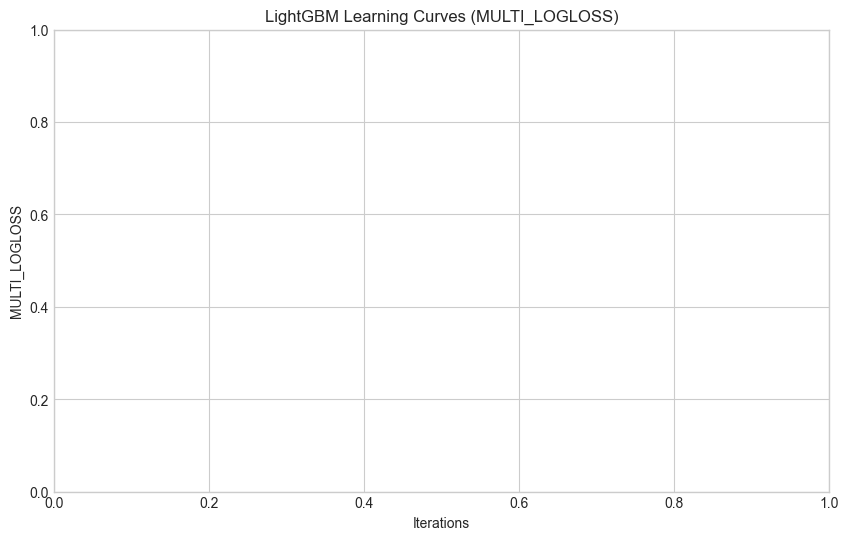

In [14]:
mviz = ModelVisualizer(model_name='LightGBM')

mviz.plot_learning_curves(eval_results, metric='multi_logloss')

### Feature Importance (Gain)

Ranks features by how much they reduced the loss function when used in a split.

* **Validation check:** `redshift`, `redshift_sq`, `redshift_log1p`, and `is_high_z` should dominate — redshift is the single strongest discriminator in SDSS stellar classification.
* **Colour check:** Colour indices (`g_minus_z`, `u_minus_r`, etc.) should rank in the mid-tier. If raw magnitudes outrank colours, verify the `colors` strategy is active.
* **Leakage check:** `id` must not appear. `alpha` and `delta` should rank near zero unless the `position` strategy is active.
* **Zero-importance features:** If any engineered features sit at zero across all folds, they failed to add signal and should be dropped from `fe_strategies` or removed from the `FeatureFactory`.

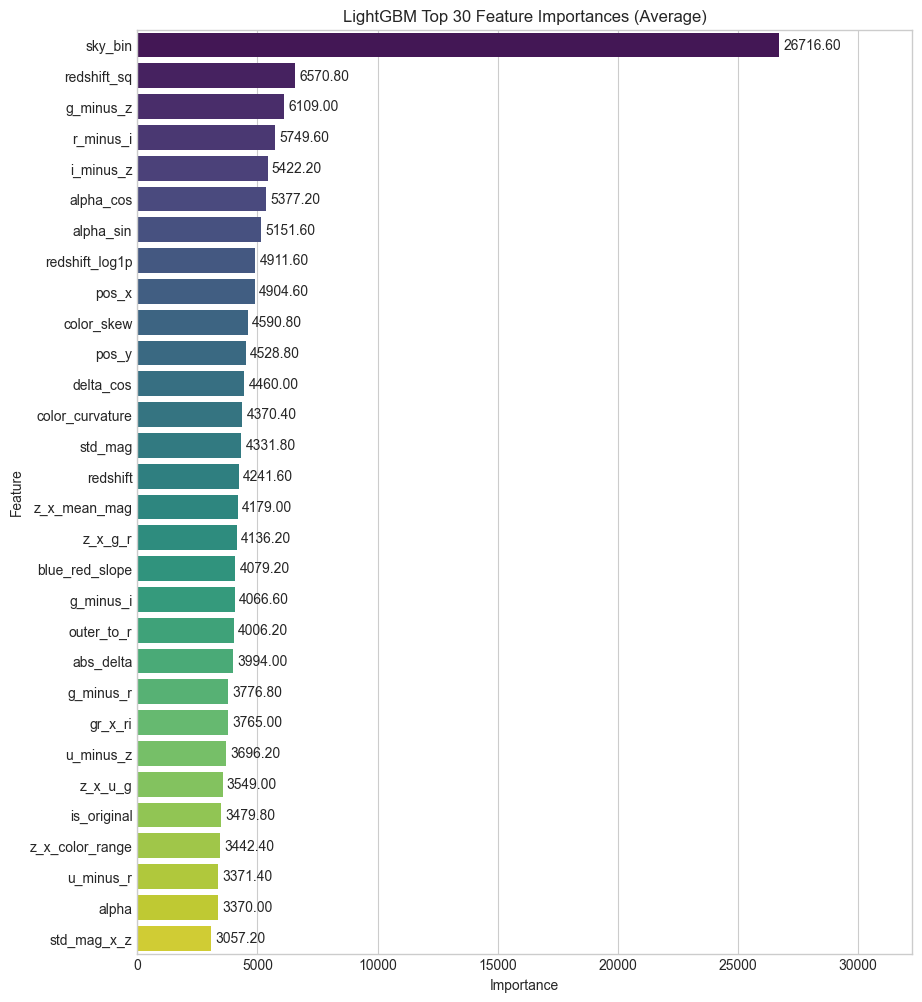

In [15]:
mviz.plot_feature_importance(models, show_values=True)

### Distribution Mismatch
Overlays the distribution of true class labels against OOF predicted labels (QSO=0, STAR=1, GALAXY=2). A large divergence on one class suggests the model is systematically misclassifying that stellar type.

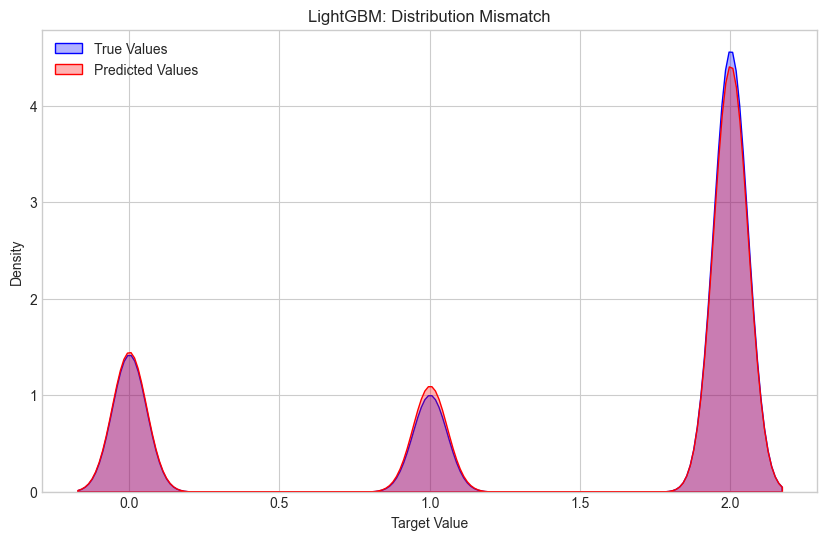

In [16]:
mviz.plot_distribution_mismatch(y_true=y[filled_mask], y_preds=oof_preds[filled_mask])

### ROC Curves (One-vs-Rest)
Each class is treated as the positive class in turn. AUC measures separation from the other two classes. All three curves should sit well above the diagonal; a sagging QSO curve is the most common weak point in stellar classification tasks.

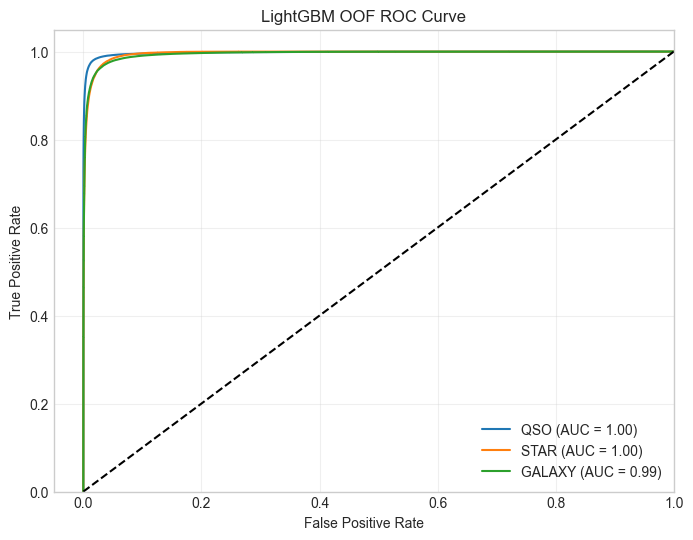

In [17]:
mviz.plot_multiclass_roc_curve(y_true=y[filled_mask], y_score=oof_probs[filled_mask], title='LightGBM OOF ROC Curve')

Normalized confusion matrix


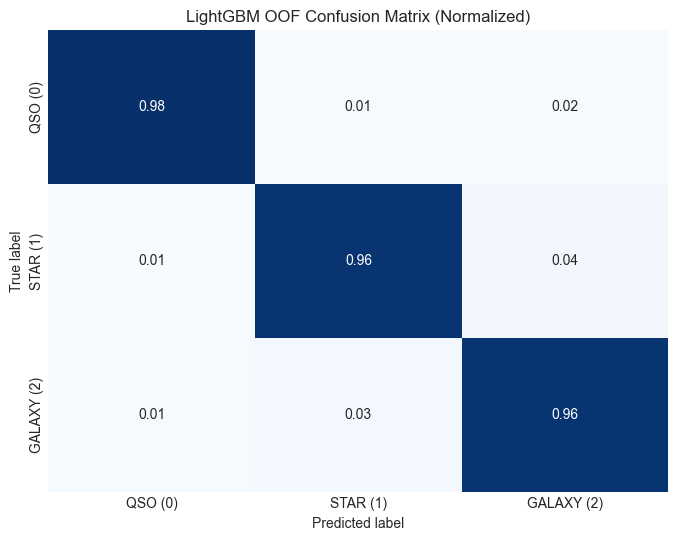

In [18]:
mviz.plot_confusion_matrix(
    y_true=y[filled_mask],
    y_pred=oof_preds[filled_mask],
    classes=['QSO (0)', 'STAR (1)', 'GALAXY (2)'],
    normalize=True,
    title='LightGBM OOF Confusion Matrix (Normalized)'
)

## Prepare Submission

The competition requires the hard predicted class label (`GALAXY`, `QSO`, or `STAR`) for each row in the test set. We derive predictions by taking the argmax of the averaged test probabilities and mapping back to the original string labels.

In [19]:
submission_df = setup.read_dataset('submission')

numeric_preds = np.argmax(test_probs, axis=1)

# Map numeric predictions back to string class labels
pred_col = [c for c in submission_df.columns if c != 'id'][0]
submission_df[pred_col] = pd.Series(numeric_preds).map(inverse_target_mapping)

print('SAMPLE SUBMISSION')
display(submission_df.head(20))


SAMPLE SUBMISSION


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
5,577352,GALAXY
6,577353,GALAXY
7,577354,STAR
8,577355,GALAXY
9,577356,GALAXY


In [20]:
submission_df.to_csv('submission.csv', index=False)
print('Saved: submission.csv')

Saved: submission.csv


## Save OOF and Test Probabilities

OOF and averaged test-set probabilities are saved for downstream ensembling (blending or stacking). For this three-class task we save the full probability distribution across `QSO`, `STAR`, and `GALAXY` rather than just the argmax labels. Raw probabilities are essential for:

- **Weighted Blending**: Averaging confidence scores across XGBoost, LightGBM, and CatBoost models.
- **Stacking**: Using these probabilities as meta-features for a secondary model.
- **Calibration Analysis**: Verifying that predicted confidence aligns with actual class frequencies.

For blending reference see Tilii's excellent [For the (recovering) blind blending addicts](https://www.kaggle.com/competitions/playground-series-s5e12/discussion/651787).

In [21]:
output_dir = 'predictions'
os.makedirs(output_dir, exist_ok=True)

# Column names match the class label mapping: QSO=0, STAR=1, GALAXY=2
prob_cols = ['prob_qso', 'prob_star', 'prob_galaxy']

# OOF probabilities
oof_prob_df = pd.DataFrame(oof_probs, columns=prob_cols)
oof_df = pd.concat([
    pd.DataFrame({'id': train_ids.values, 'target': y.values}),
    oof_prob_df
], axis=1)
oof_df = oof_df[filled_mask]
oof_df.to_csv(f'{output_dir}/lgb_oof_probs.csv', index=False)

# Test probabilities
test_prob_df = pd.concat([
    pd.DataFrame({'id': test_ids.values}),
    pd.DataFrame(test_probs, columns=prob_cols)
], axis=1)
test_prob_df.to_csv(f'{output_dir}/lgb_test_probs.csv', index=False)

print(f'Saved for ensembling:\n - {output_dir}/lgb_oof_probs.csv\n - {output_dir}/lgb_test_probs.csv')


Saved for ensembling:
 - predictions/lgb_oof_probs.csv
 - predictions/lgb_test_probs.csv
